# La struttura della Galassia


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table


In [3]:
gaia = Table.read("data/7e0ddc65-239f-11f1-995e-bc97e148b76b-O-result.vot.gz")

In [4]:
print(len(gaia))

349153


In [5]:
# Posizione(l, b)
l = gaia['l']
b = gaia['b']

# Parallasse
parallax = gaia['parallax']
parallax_err = gaia['parallax_error']

# Velocità Radiale
rv = gaia['radial_velocity']
rv_err = gaia['radial_velocity_error']

# Moto Proprio
pmra = gaia['pmra']
pmdec = gaia['pmdec']

# Considerare solo stelle vicine al piano galattico
mask = (
    (np.abs(b) < 5) &
    (parallax > 0) &
    (parallax_err / parallax < 0.2) &
    (~np.isnan(rv))
)

data = gaia[mask]

# pick first 10000 stars
data = data[:10000]

# distance is not in parsecs, but in milliarcseconds
distance = 1000 / data['parallax']
data['distance'] = distance

In [6]:
print(data.colnames)
print(len(data))

['ra', 'dec', 'parallax', 'parallax_error', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity', 'radial_velocity_error', 'l', 'b', 'distance']
10000


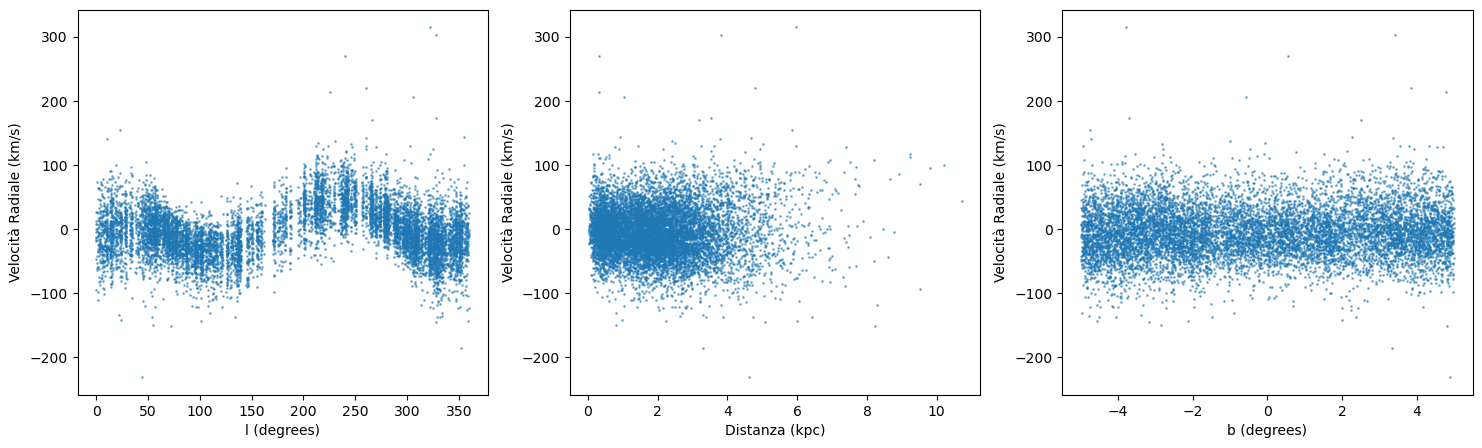

In [10]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 5))
axes[0].scatter(data['l'], data['radial_velocity'], s=1, alpha=0.5)
axes[0].set_xlabel('l (degrees)')
axes[0].set_ylabel('Velocità Radiale (km/s)')
#axes[0].set_ylim(0, 200)
axes[1].scatter(1/data['parallax'], data['radial_velocity'],s=1, alpha=0.5, )
axes[1].set_ylabel('Velocità Radiale (km/s)')
axes[1].set_xlabel('Distanza (kpc)')

axes[2].scatter(data['b'], data['radial_velocity'], s=1, alpha=0.5)
axes[2].set_xlabel('b (degrees)')
axes[2].set_ylabel('Velocità Radiale (km/s)')

plt.show()

In [11]:
import emcee

In [ ]:
# likelihood

R_sun = 8200  # kpc

def R_star(d, l):
    return np.sqrt(d**2 + R_sun**2 - 2 * d * R_sun * np.cos(np.radians(l)))

def fun_model(V_rot, l, d, U_sun, V_sun):
    return V_rot * (R_sun/R_star(d, l) - 1) * np.sin(np.radians(l)) - U_sun * np.cos(np.radians(l)) - V_sun * np.sin(np.radians(l))

def log_likelihood(theta, l, b, d, rv, rv_err):
    V_rot, U_sun, V_sun = theta
    model = fun_model(V_rot, l, d, U_sun, V_sun)
    # expect gaussian distribution for the measurements
    sigma2 = rv_err ** 2
    return -0.5 * np.sum((rv - model) ** 2 / sigma2 + np.log(sigma2))


In [13]:
# uninformative priors using uniform distributions

def log_prior(theta):
    V_rot, U_sun, V_sun = theta
    if 0 < V_rot < 300 and -30 < U_sun < 30 and -30 < V_sun < 30: # add U_sun and V_sun priors
        return 0.0
    else:
        return -np.inf

def log_probability(theta, l, b, d, rv, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, l, b, d, rv, rv_err)


In [20]:
nwalkers = 32
ndim = 3
# create 32 walker, each with 3 parameters uniformly distributed
pos = np.array([np.random.uniform(0, 300, size=(nwalkers)), np.random.uniform(-30, 30, size=(nwalkers)), np.random.uniform(-30, 30, size=(nwalkers))]).T

print(pos.shape)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim,
    log_probability, 
    args=(data['l'].data, data['b'].data, data['distance'].data, data['radial_velocity'].data, data['radial_velocity_error'].data)
)
sampler.run_mcmc(pos, 5000, progress=True)

(32, 3)


100%|██████████| 5000/5000 [05:03<00:00, 16.49it/s]


State([[204.74637971   9.80980306  21.66114828]
 [204.81393252   9.79558522  21.66074405]
 [204.71585551   9.80616965  21.66277155]
 [204.82835645   9.81121236  21.65422252]
 [204.8150526    9.80514229  21.6667853 ]
 [204.73132574   9.80301264  21.65477396]
 [204.8218077    9.80200399  21.65804829]
 [204.75856467   9.8241752   21.66940847]
 [204.78709709   9.80609019  21.6622839 ]
 [204.67292088   9.81218367  21.64923278]
 [204.66768389   9.79649033  21.66915455]
 [204.76980915   9.81556958  21.66207547]
 [204.70990374   9.79182807  21.66770624]
 [204.80961695   9.80536067  21.65051476]
 [204.70620224   9.80668062  21.65959243]
 [204.7434473    9.81057439  21.6706462 ]
 [204.75999542   9.81584473  21.66663545]
 [204.71288726   9.79858462  21.65859585]
 [204.6744829    9.80033443  21.66723755]
 [204.77519673   9.80796517  21.65979426]
 [204.70187059   9.81002222  21.66564698]
 [204.73664186   9.79012081  21.67352821]
 [204.72043029   9.80381669  21.66887473]
 [204.77066219   9.81147244 

In [21]:
samples = sampler.get_chain()
print(f"MCMC shape: {samples.shape}")  # (steps, walkers, ndim)

MCMC shape: (5000, 32, 3)


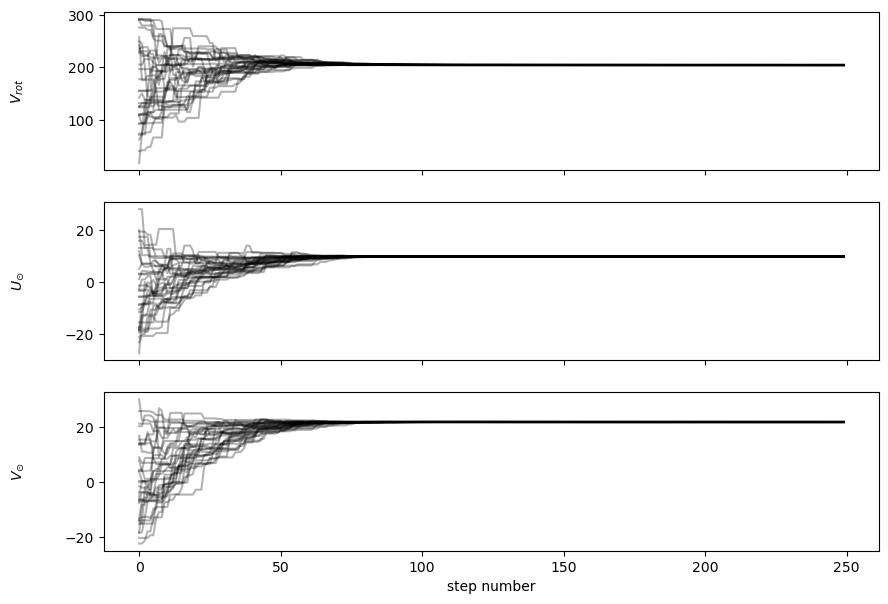

In [37]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
labels = ["$V_{rot}$", "$U_{\odot}$", "$V_{\odot}$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i][:250], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

Autocorrelation time: 21.83
Flattened samples shape: (10432, 3)


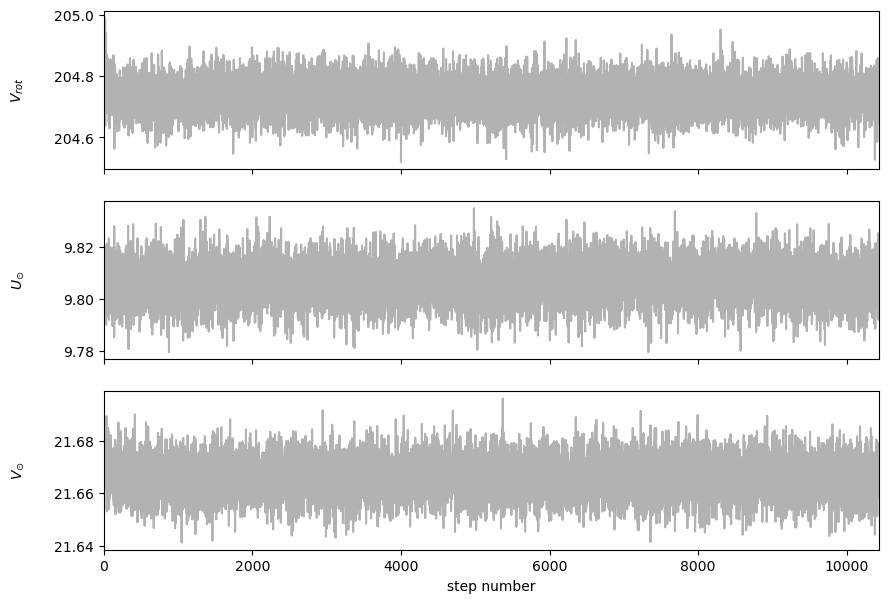

In [38]:
# Check autocorrelation time and convergence
tau = sampler.get_autocorr_time()
print(f"Autocorrelation time: {tau[0]:.2f}")

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(f"Flattened samples shape: {flat_samples.shape}")

# plot flat samples
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(flat_samples[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(flat_samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number");

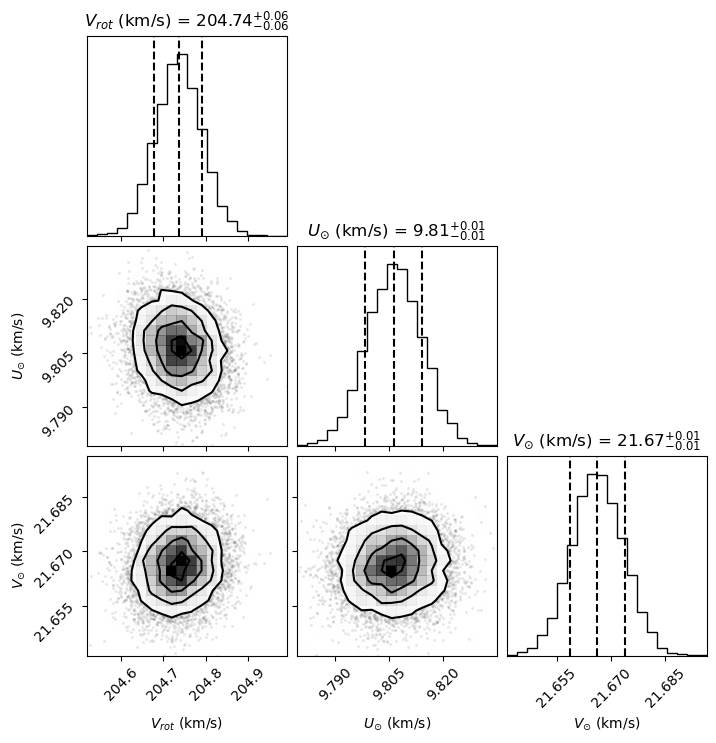

In [35]:
import corner

# add percentile lines to corners

fig = corner.corner(
    flat_samples, labels=[
    "$V_{rot}$ (km/s)", "$U_{\odot}$ (km/s)", "$V_{\odot}$ (km/s)"
    ],
    quantiles=[0.15, 0.5, 0.85],
    show_titles=True, title_kwargs={"fontsize": 12}

)
plt.show()

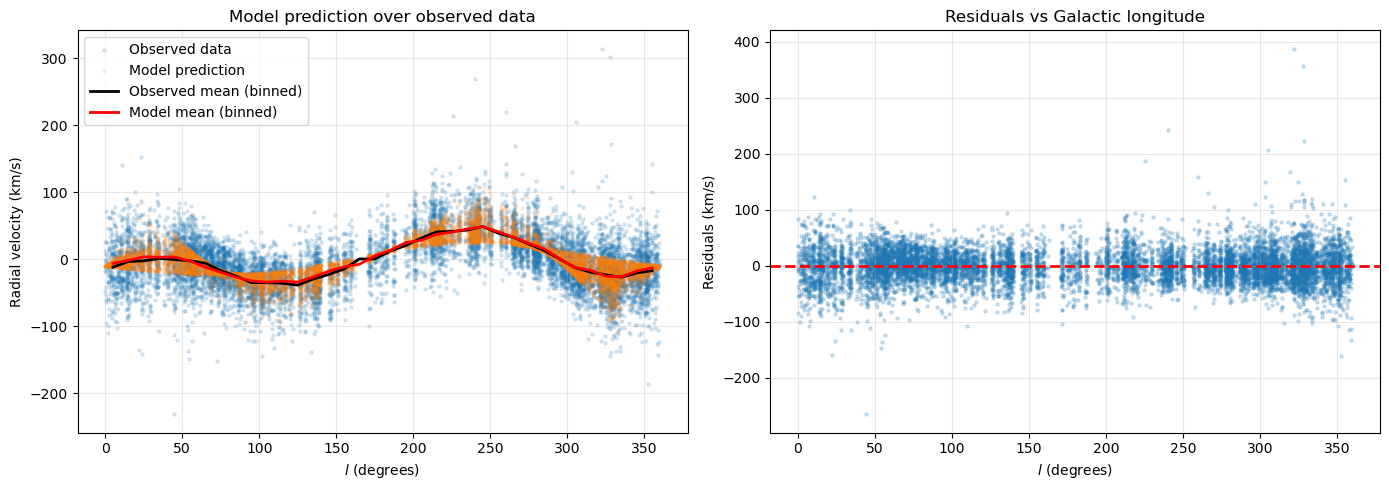

In [36]:
# Use posterior median parameters when available; otherwise fallback to least-squares
theta_hat = np.median(flat_samples, axis=0)


V_rot_hat, U_sun_hat, V_sun_hat = theta_hat

# Predict radial velocity for each star using its own distance
l_obs = np.asarray(data['l'].data)
d_obs = np.asarray(data['distance'].data)
rv_obs = np.asarray(data['radial_velocity'].data)
rv_pred = fun_model(V_rot_hat, l_obs, d_obs, U_sun_hat, V_sun_hat)

# Build binned trends vs Galactic longitude for a clearer overlay
bins = np.linspace(0, 360, 37)  # 10-degree bins
centers = 0.5 * (bins[:-1] + bins[1:])
obs_binned = np.full(len(centers), np.nan)
pred_binned = np.full(len(centers), np.nan)

for i in range(len(centers)):
    in_bin = (l_obs >= bins[i]) & (l_obs < bins[i + 1])
    if np.any(in_bin):
        obs_binned[i] = np.mean(rv_obs[in_bin])
        pred_binned[i] = np.mean(rv_pred[in_bin])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data + model overlay
ax = axes[0]
ax.scatter(l_obs, rv_obs, s=5, alpha=0.15, label='Observed data')
ax.scatter(l_obs, rv_pred, s=5, alpha=0.10, label='Model prediction')
ax.plot(centers, obs_binned, 'k-', linewidth=2, label='Observed mean (binned)')
ax.plot(centers, pred_binned, 'r-', linewidth=2, label='Model mean (binned)')
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Radial velocity (km/s)')
ax.set_title('Model prediction over observed data')
ax.grid(alpha=0.3)
ax.legend()

# Residuals
ax = axes[1]
residuals = rv_obs - rv_pred
ax.scatter(l_obs, residuals, s=5, alpha=0.2)
ax.axhline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Residuals (km/s)')
ax.set_title('Residuals vs Galactic longitude')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

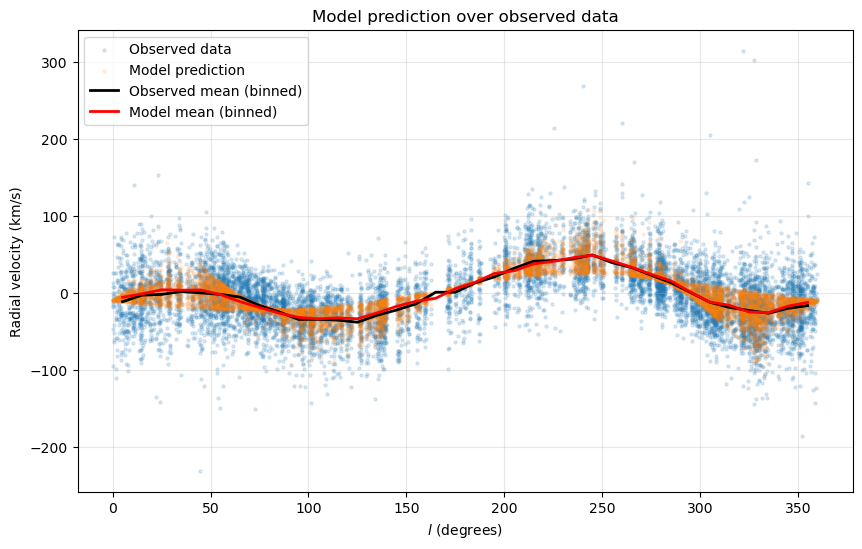

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(l_obs, rv_obs, s=5, alpha=0.15, label='Observed data')
ax.scatter(l_obs, rv_pred, s=5, alpha=0.10, label='Model prediction')
ax.plot(centers, obs_binned, 'k-', linewidth=2, label='Observed mean (binned)')
ax.plot(centers, pred_binned, 'r-', linewidth=2, label='Model mean (binned)')
ax.set_xlabel('$l$ (degrees)')
ax.set_ylabel('Radial velocity (km/s)')
ax.set_title('Model prediction over observed data')
ax.grid(alpha=0.3)
ax.legend()

plt.show()

In [39]:
# likelihood

def R_star(d, l):
    return np.sqrt(d**2 + R_sun**2 - 2 * d * R_sun * np.cos(np.radians(l)))

def err_vrad_d(d, parallax_err, V_rot, l):
    num = V_rot * R_sun * (R_sun * np.cos(np.radians(l)) - d)
    den = np.sqrt((R_sun**2 + d**2 - 2 * d * R_sun * np.cos(np.radians(l))**3))
    der = num / den
    return der * parallax_err * (d**2 / 1000)

def log_likelihood_d(theta, l, b, d, rv, rv_err, parallax_err):
    V_rot, U_sun, V_sun = theta
    model = fun_model(V_rot, l, d, U_sun, V_sun)
    # expect gaussian distribution for the measurements
    sigma2 = rv_err ** 2 + err_vrad_d(d, parallax_err, V_rot, l) ** 2
    return -0.5 * np.sum((rv - model) ** 2 / sigma2 + np.log(sigma2))

In [40]:
# uninformative priors using uniform distributions

def log_prior(theta):
    V_rot, U_sun, V_sun = theta
    if 0 < V_rot < 300 and -30 < U_sun < 30 and -30 < V_sun < 30: # add U_sun and V_sun priors
        return 0.0
    else:
        return -np.inf

def log_probability_d(theta, l, b, d, rv, rv_err, parallax_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_d(theta, l, b, d, rv, rv_err, parallax_err)


In [41]:
nwalkers = 32
ndim = 3
# create 32 walker, each with 3 parameters uniformly distributed
pos_d = np.array([np.random.uniform(0, 300, size=(nwalkers)), np.random.uniform(-30, 30, size=(nwalkers)), np.random.uniform(-30, 30, size=(nwalkers))]).T

print(pos_d.shape)

sampler_d = emcee.EnsembleSampler(
    nwalkers, ndim,
    log_probability_d, 
    args=(data['l'].data, data['b'].data, data['distance'].data, data['radial_velocity'].data, data['radial_velocity_error'].data, data['parallax_error'].data)
)
sampler_d.run_mcmc(pos_d, 5000, progress=True)

(32, 3)


100%|██████████| 5000/5000 [08:12<00:00, 10.15it/s]


State([[ 5.70272474e-03 -9.59443542e+00  7.38736327e+00]
 [ 5.61684632e-03 -1.06078753e+01  7.44007800e+00]
 [ 5.66690920e-03 -9.35656021e+00  7.44350946e+00]
 [ 5.72615436e-03 -1.04518210e+01  7.62043925e+00]
 [ 5.65917758e-03 -1.05347720e+01  7.43129802e+00]
 [ 5.72932946e-03 -1.00887749e+01  7.40359809e+00]
 [ 5.78137513e-03 -1.01181020e+01  7.42548028e+00]
 [ 5.75131330e-03 -9.46050828e+00  7.59641277e+00]
 [ 5.77993704e-03 -9.80631287e+00  7.43137502e+00]
 [ 5.70179822e-03 -9.09593417e+00  7.21732092e+00]
 [ 5.66719853e-03 -9.66691058e+00  7.62539848e+00]
 [ 5.74091931e-03 -9.46798483e+00  7.28406885e+00]
 [ 5.66990581e-03 -9.36221793e+00  7.48049703e+00]
 [ 5.76541500e-03 -1.09082017e+01  7.64633735e+00]
 [ 5.63098081e-03 -9.84145175e+00  7.55208315e+00]
 [ 5.75375248e-03 -1.04677721e+01  7.45038632e+00]
 [ 5.74656427e-03 -9.69719449e+00  7.28897688e+00]
 [ 5.71904561e-03 -8.73690946e+00  7.45108033e+00]
 [ 5.72323441e-03 -9.26202000e+00  7.32644843e+00]
 [ 5.70916582e-03 -9.7030

MCMC shape: (5000, 32, 3)


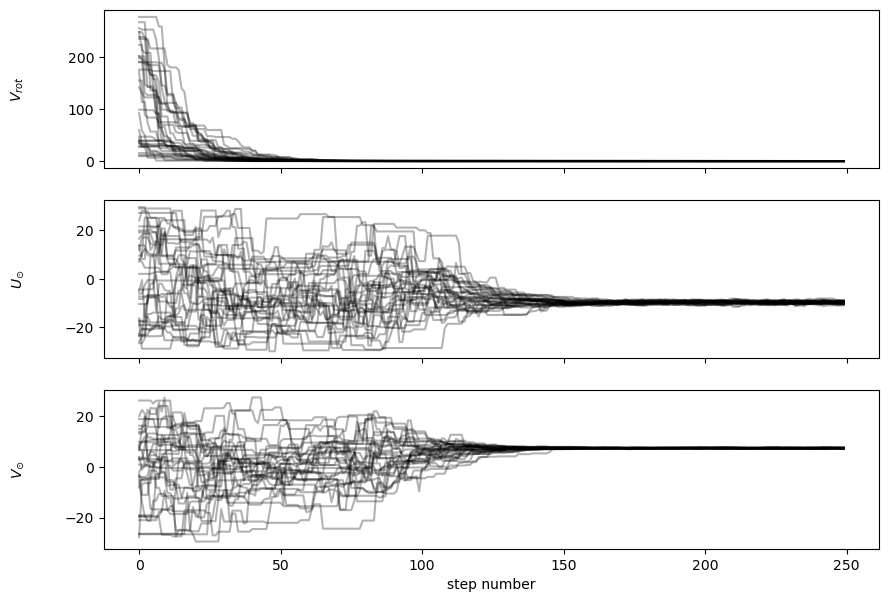

In [42]:
samples_d = sampler_d.get_chain()
print(f"MCMC shape: {samples_d.shape}")  # (steps, walkers, ndim)

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
labels = ["$V_{rot}$", "$U_{\odot}$", "$V_{\odot}$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_d[:, :, i][:250], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

Autocorrelation time: 23.12
Flattened samples shape: (10432, 3)


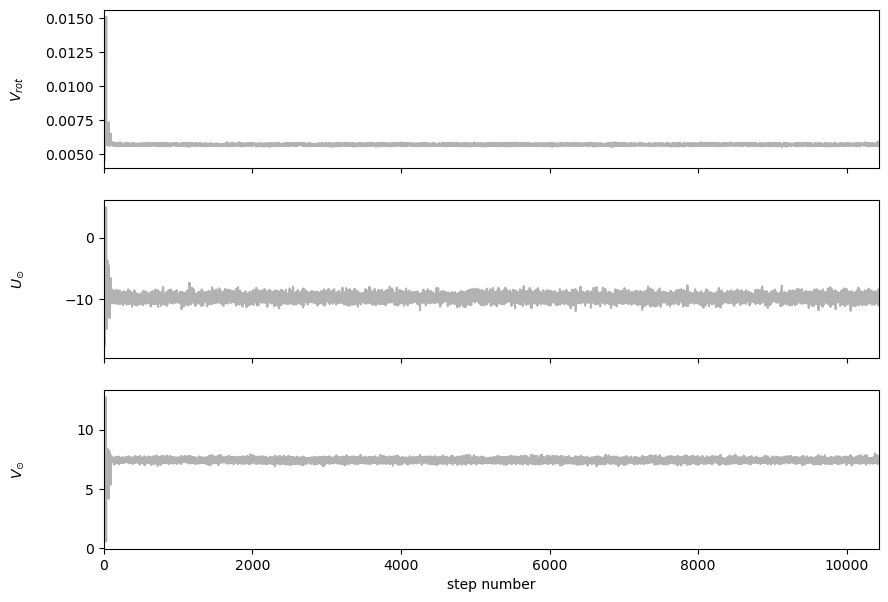

In [43]:
# Check autocorrelation time and convergence
tau = sampler_d.get_autocorr_time()
print(f"Autocorrelation time: {tau[0]:.2f}")

flat_samples_d = sampler_d.get_chain(discard=100, thin=15, flat=True)
print(f"Flattened samples shape: {flat_samples_d.shape}")

# plot flat samples
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(flat_samples_d[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(flat_samples_d))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number");

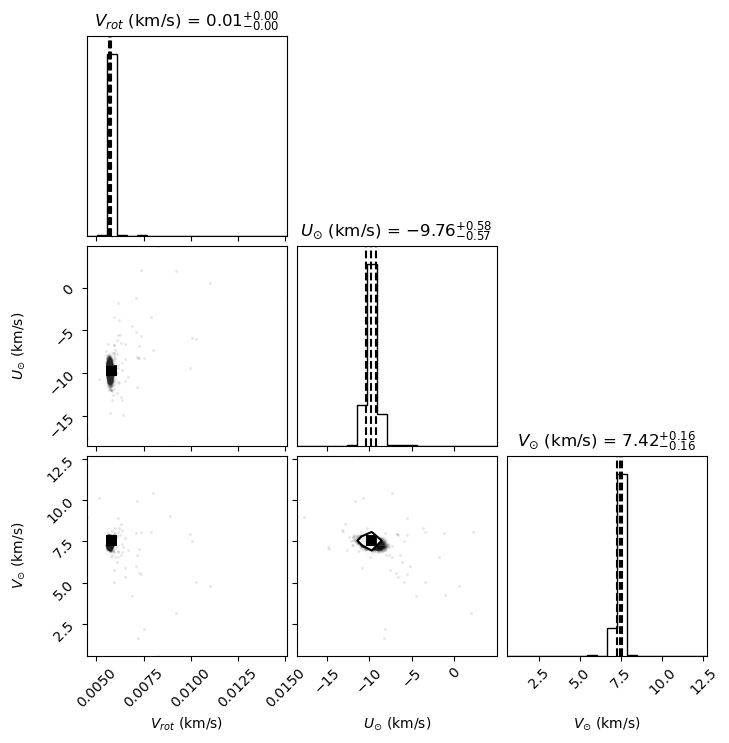

In [44]:
fig = corner.corner(
    flat_samples_d, labels=[
    "$V_{rot}$ (km/s)", "$U_{\odot}$ (km/s)", "$V_{\odot}$ (km/s)"
    ],
    quantiles=[0.15, 0.5, 0.85],
    show_titles=True, title_kwargs={"fontsize": 12}

)
plt.show()